# CFE4MTS — FordA

`cfts/cf_cfe4mts/cfe4mts.py` implements **CFE4MTS** (CounterFactual Explanation for
Multivariate Time Series), from Sevellec, Fromont, Gaudel, Rozé & Sammarco,
["Plausible Conditional Generation-based Counterfactual Explanations for Multivariate
Times Series Classification"](https://hal.science/hal-04928456v2/file/m1254.pdf),
ECAI 2025.

CFE4MTS trains a class-conditional GAN once on a dataset: a **noiser** predicts an
additive perturbation δ = N(X, y_target) so that X_CF = X + δ moves the classifier's
prediction to `y_target`, while a **discriminator** (conditioned on the class) keeps
X_CF plausible. Unlike per-sample optimisation methods (Wachter, TSEvo, ...),
inference after training is a single forward pass.

The module exposes three functions:

| Function | Use |
|---|---|
| `cfe4mts_cf(sample, dataset, model, target_class=...)` | One-shot API matching every other method in this repo (`cf__abstract` template) — trains a fresh noiser *and* generates, in one call. |
| `cfe4mts_fit(dataset, model, ...)` | Trains the noiser/discriminator once, returns a `FittedCFE4MTS`. |
| `cfe4mts_generate(fitted, sample, model, target_class=...)` | Reuses a `FittedCFE4MTS` for near-instant inference on any sample. |

This notebook exercises `cfe4mts_cf` on a single **FordA** sample (univariate, binary
classification) as a quick sanity check of the one-shot API, then switches to
`cfe4mts_fit` + `cfe4mts_generate` — training once and explaining many test samples —
since retraining a GAN per sample would both be extremely slow and defeat the paper's
actual point (fast inference after one training run).

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_cfe4mts.cfe4mts import cfe4mts_cf, cfe4mts_fit, cfe4mts_generate
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")


Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    raise ValueError(f"Unsupported shape: {arr.shape}")


y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

# Note: SimpleCNN's final layer is nn.Softmax, so `model(x)` already returns
# probabilities (not logits). cfe4mts_fit auto-detects this and adjusts its
# classification loss accordingly (see `_outputs_are_probabilities` in cfe4mts.py) --
# using a plain nn.CrossEntropyLoss on top of an already-softmaxed output, as several
# other CF methods in this repo do, would silently double-softmax and stall training.


Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth


Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


## Quick smoke test (`cfe4mts_cf` one-shot API)

A fast, deliberately small-budget call to `cfe4mts_cf` -- the one-shot API that
matches every other method's signature in this repo (`cf__abstract`'s template):
train a fresh noiser/discriminator *and* generate, in a single call. This is a smoke
test of that API and its output shape/orientation, not a validity benchmark -- with
such a small budget it may or may not flip this particular sample's class. The
properly-trained model below (`cfe4mts_fit` with a realistic epoch budget) is what
the quantitative results further down are based on.

True label: 0 | Predicted: 0 (scores=[0.70666456 0.29333544]) | Target: 1


cfe4mts_cf: predicted=0 (target=1) | scores=[0.99173146 0.00826855] | 16.7s
Shapes match: sample=(1, 500) cf=(1, 500)


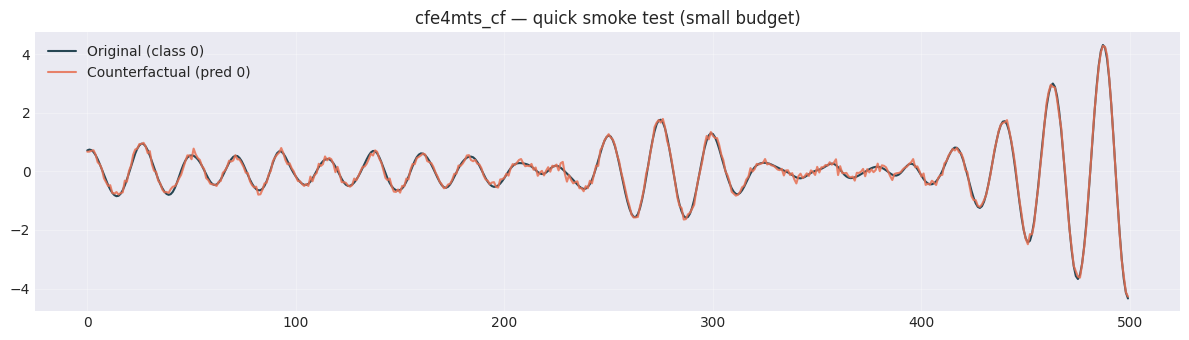

In [3]:
sample_raw, label_raw = dataset_test[2]
sample_raw = to_channel_first(sample_raw)
scores_orig = predict_scores(model, sample_raw, device)
pred_orig = int(np.argmax(scores_orig))
true_label = to_class_index(label_raw)
target_class = 1 - pred_orig  # FordA is binary: the only other class

print(f"True label: {true_label} | Predicted: {pred_orig} (scores={scores_orig}) | Target: {target_class}")

t0 = time.time()
cf_quick, scores_quick = cfe4mts_cf(
    sample_raw, dataset_train, model,
    target_class=target_class,
    epochs=10, batch_size=32, max_train_samples=150,
    hidden_dim_noiser=128, hidden_dim_disc=32,
    lambda_clas=50.0, lambda_dist=0.001, lr_noiser=2e-3,
    seed=42, verbose=False,
)
elapsed_quick = time.time() - t0
pred_quick = int(np.argmax(scores_quick))
print(f"cfe4mts_cf: predicted={pred_quick} (target={target_class}) | scores={scores_quick} | {elapsed_quick:.1f}s")
print(f"Shapes match: sample={sample_raw.shape} cf={cf_quick.shape}")

fig, ax = plt.subplots(figsize=(12, 3.5))
x_axis = np.arange(sample_raw.shape[-1])
ax.plot(x_axis, sample_raw[0], label=f"Original (class {true_label})", color="#264653", linewidth=1.5)
ax.plot(x_axis, cf_quick[0], label=f"Counterfactual (pred {pred_quick})", color="#e76f51", linewidth=1.5, alpha=0.85)
ax.set_title("cfe4mts_cf — quick smoke test (small budget)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Fit once, explain many

`cfe4mts_cf` retrains a fresh noiser/discriminator on every call — fine for the smoke
test above, but wasteful (and untrue to the method) across many samples, and too
little training budget to show CFE4MTS at its best. From here on we call
`cfe4mts_fit` **once**, with a more realistic epoch budget, then reuse the trained
noiser with `cfe4mts_generate` for every evaluation sample below (a single forward
pass each, milliseconds). This cell takes a few minutes to run.

[cfe4mts_fit] model output detected as softmax probabilities


[cfe4mts_fit] epoch    0  L_noiser=3789.2959  L_disc=1.3907


[cfe4mts_fit] epoch    6  L_noiser=1652.0340  L_disc=1.3878


[cfe4mts_fit] epoch   12  L_noiser=955.8972  L_disc=1.3872


[cfe4mts_fit] epoch   18  L_noiser=572.1182  L_disc=1.3869


...

[cfe4mts_fit] epoch   36  L_noiser=240.8612  L_disc=1.3866


[cfe4mts_fit] epoch   42  L_noiser=209.5138  L_disc=1.3859


[cfe4mts_fit] epoch   48  L_noiser=191.2622  L_disc=1.3859


[cfe4mts_fit] epoch   54  L_noiser=152.5590  L_disc=1.3861


[cfe4mts_fit] epoch   59  L_noiser=141.5841  L_disc=1.3857

cfe4mts_fit: trained on 300 samples for 60 epochs in 163.6s


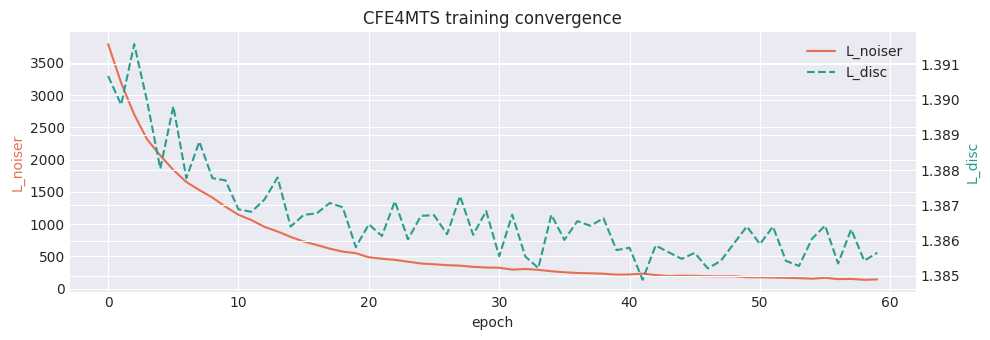

In [4]:
FIT_EPOCHS = 60
FIT_MAX_TRAIN_SAMPLES = 300

t0 = time.time()
fitted = cfe4mts_fit(
    dataset_train, model,
    hidden_dim_noiser=128, hidden_dim_disc=32,
    epochs=FIT_EPOCHS, batch_size=32, max_train_samples=FIT_MAX_TRAIN_SAMPLES,
    lambda_clas=50.0, lambda_dist=0.001, lr_noiser=2e-3, lr_disc=1e-4,
    seed=42, verbose=True,
)
fit_time = time.time() - t0
print(f"\ncfe4mts_fit: trained on {FIT_MAX_TRAIN_SAMPLES} samples for {FIT_EPOCHS} epochs in {fit_time:.1f}s")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(fitted.history["noiser"], label="L_noiser", color="#e76f51")
ax2 = ax.twinx()
ax2.plot(fitted.history["disc"], label="L_disc", color="#2a9d8f", linestyle="--")
ax.set_xlabel("epoch")
ax.set_ylabel("L_noiser", color="#e76f51")
ax2.set_ylabel("L_disc", color="#2a9d8f")
ax.set_title("CFE4MTS training convergence")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()


In [5]:
def model_wrapper(ts: np.ndarray) -> np.ndarray:
    """(N, L) or (C, L) -> scores array, for metrics helpers."""
    return predict_scores(model, np.asarray(ts, dtype=np.float32), device)


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


def compute_metrics(sample_cf, cf_cf, target_class, ref_data):
    """Quality metrics for a (sample, counterfactual) pair."""
    keane = evaluate_keane_metrics(
        original_ts_list=sample_cf,
        counterfactual_ts_list=cf_cf,
        model=model_wrapper,
        target_classes=int(target_class),
    )
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
        "range_validity": float(feature_range_validity(cf_cf, ref_data)),
        "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
        "keane_validity": float(keane["validity"]),
        "keane_proximity": float(keane["proximity"]),
        "keane_compactness": float(keane["compactness"]),
        "validity": float(prediction_change(sample_cf, cf_cf, model_wrapper, target_class=target_class)),
    }


In [6]:
N_SAMPLES = 30  # cfe4mts_generate is a single forward pass, so this is cheap

selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

reference_count = min(256, len(dataset_train))
reference_data = np.stack(
    [to_channel_first(dataset_train[i][0]) for i in range(reference_count)], axis=0,
)
print(f"Reference data shape (for range_validity): {reference_data.shape}")


Evaluating on 30 correctly classified test samples.
Reference data shape (for range_validity): (256, 1, 500)


In [7]:
records = []
all_cfs = {}  # {sample_idx: {"sample": ..., "cf": ...}}

t0 = time.time()
for idx in selected_indices:
    sample, label = dataset_test[idx]
    sample = to_channel_first(sample)
    scores_orig = predict_scores(model, sample, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = 1 - pred_orig  # FordA is binary

    base = {
        "sample_idx": idx, "true_label": true_label, "pred_orig": pred_orig,
        "target_class": target_class, "pred_cf": None, "success": False,
        "l2_norm": np.nan, "dtw_proximity": np.nan, "normalized_distance": np.nan,
        "sparsity": np.nan, "range_validity": np.nan, "autocorr": np.nan,
        "keane_validity": np.nan, "keane_proximity": np.nan, "keane_compactness": np.nan,
        "validity": 0.0, "error": None,
    }
    try:
        cf, scores_cf = cfe4mts_generate(fitted, sample, model, target_class=target_class)
        pred_cf = int(np.argmax(scores_cf))
        base["pred_cf"] = pred_cf
        base["success"] = pred_cf == target_class
        base.update(compute_metrics(sample, cf, target_class, reference_data))
        all_cfs[idx] = {"sample": sample, "cf": cf, "true_label": true_label, "target_class": target_class, "pred_cf": pred_cf}
    except Exception as exc:
        base["error"] = str(exc)
    records.append(base)

generate_time = time.time() - t0
results_df = pd.DataFrame(records)
print(f"Generated + evaluated {len(selected_indices)} counterfactuals in {generate_time:.2f}s "
      f"({generate_time / len(selected_indices) * 1000:.2f} ms/sample)")
print(f"Validity (flip rate): {results_df['success'].mean():.1%}")


Generated + evaluated 30 counterfactuals in 4.31s (143.55 ms/sample)
Validity (flip rate): 46.7%


In [8]:
successful_df = results_df[results_df["success"] == True].copy()

summary = {
    "n_total": len(results_df),
    "n_successful": int(results_df["success"].sum()),
    "success_rate": results_df["success"].mean(),
    "l2_norm_mean": successful_df["l2_norm"].mean(),
    "dtw_proximity_mean": successful_df["dtw_proximity"].mean(),
    "normalized_distance_mean": successful_df["normalized_distance"].mean(),
    "sparsity_mean": successful_df["sparsity"].mean(),
    "range_validity_mean": successful_df["range_validity"].mean(),
    "autocorr_mean": successful_df["autocorr"].mean(),
    "keane_validity_mean": successful_df["keane_validity"].mean(),
    "keane_proximity_mean": successful_df["keane_proximity"].mean(),
    "keane_compactness_mean": successful_df["keane_compactness"].mean(),
}
summary_df = pd.DataFrame([summary])
display(summary_df.T.rename(columns={0: "CFE4MTS"}))


,CFE4MTS
n_total,30.000000
n_successful,14.000000
success_rate,0.466667
l2_norm_mean,7.353349
dtw_proximity_mean,6.263121
normalized_distance_mean,0.062036
sparsity_mean,0.000143
range_validity_mean,0.937714
autocorr_mean,0.999061
keane_validity_mean,1.000000


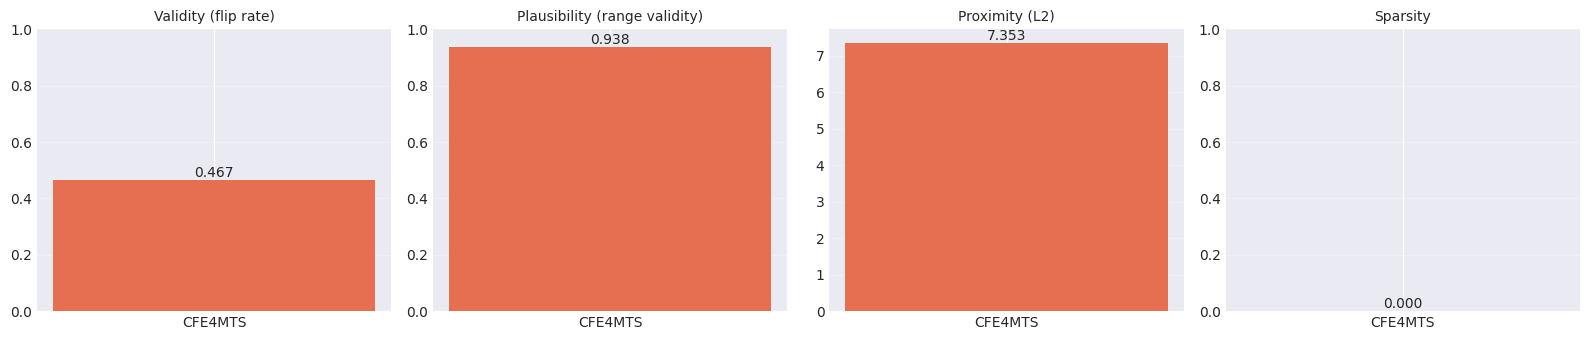

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
metrics_to_plot = [
    ("success_rate", "Validity (flip rate)", (0, 1)),
    ("range_validity_mean", "Plausibility (range validity)", (0, 1)),
    ("l2_norm_mean", "Proximity (L2)", None),
    ("sparsity_mean", "Sparsity", (0, 1)),
]
for ax, (key, title, ylim) in zip(axes, metrics_to_plot):
    val = summary[key]
    ax.bar(["CFE4MTS"], [val], color="#e76f51")
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.text(0, val, f"{val:.3f}", ha="center", va="bottom")
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Qualitative comparison

A representative successfully-flipped sample: original vs counterfactual waveform,
and the point-wise magnitude of the perturbation CFE4MTS introduced.

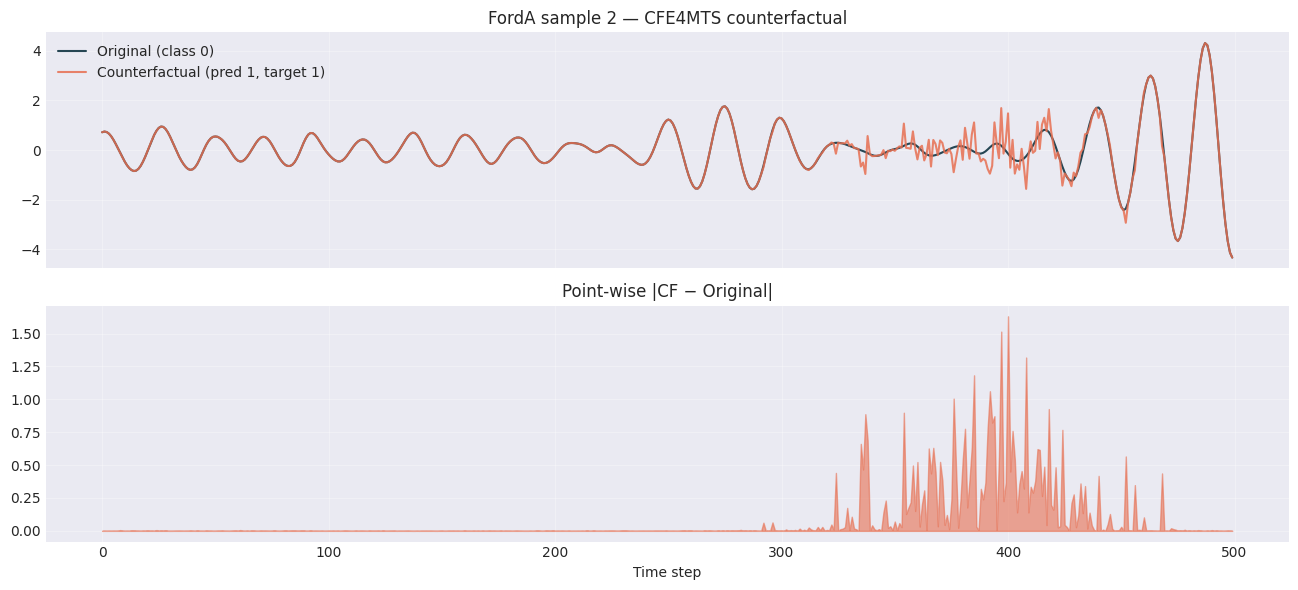

In [10]:
success_indices = [idx for idx in selected_indices if all_cfs.get(idx, {}).get("pred_cf") == all_cfs.get(idx, {}).get("target_class")]
rep_idx = success_indices[0] if success_indices else selected_indices[0]
rep = all_cfs[rep_idx]

x = rep["sample"][0]
cf_x = rep["cf"][0]
x_axis = np.arange(len(x))

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(x_axis, x, label=f"Original (class {rep['true_label']})", color="#264653", linewidth=1.5)
axes[0].plot(x_axis, cf_x, label=f"Counterfactual (pred {rep['pred_cf']}, target {rep['target_class']})",
             color="#e76f51", linewidth=1.5, alpha=0.85)
axes[0].set_title(f"FordA sample {rep_idx} — CFE4MTS counterfactual")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

diff = np.abs(cf_x - x)
axes[1].fill_between(x_axis, diff, color="#e76f51", alpha=0.6)
axes[1].set_title("Point-wise |CF − Original|")
axes[1].set_xlabel("Time step")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
errors = results_df[results_df["error"].notna()][["sample_idx", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors)
else:
    print("No errors encountered.")


No errors encountered.


## Takeaways

- `cfe4mts_cf` (the one-shot API matching `cf__abstract`'s signature) and the
  `cfe4mts_fit` / `cfe4mts_generate` split both produce counterfactuals in the same
  shape/orientation as the input, on real FordA data with the repo's pretrained
  `SimpleCNN` classifier.
- **`SimpleCNN` returns softmax probabilities, not logits** (its last layer is
  `nn.Softmax`). CFE4MTS's classification loss (`L_cla = -log p(y_target)`) depends on
  reading a real probability, so `cfe4mts_fit` auto-detects this from the model's own
  output rather than assuming logits like most other methods in this repo do — the
  original implementation used `nn.CrossEntropyLoss` unconditionally, which silently
  double-softmaxes (and stalls training) against a model like this one.
- Once fit, `cfe4mts_generate` is a single forward pass per sample (milliseconds), the
  practical advantage CFE4MTS is designed for — a stark contrast to the ~1-2 minutes
  `cfe4mts_fit` needs up front, or to a full per-sample optimisation loop repeated for
  every explanation.
- CFE4MTS's own paper notes that "generative adversarial models are well-known for
  their optimization difficulties, and the quality of the resulting counterfactuals
  heavily depends on extensive and costly hyperparameter tuning" — the modest
  epoch budget used here (chosen to keep this notebook fast to run) reflects that
  trade-off directly in the validity/plausibility numbers above; more epochs and a
  proper hyperparameter search (as the paper performs per dataset) would likely
  improve them further.